<a href="https://colab.research.google.com/github/wowiimvidya08-hue/Vidyottama-Vinod-Assignment/blob/main/Vidyottamaipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loading and normalizing CIFAR-10 dataset...
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Building and training Autoencoder...
Epoch 1/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 102s 508ms/step - loss: 0.6335 - val_loss: 0.5830
Epoch 2/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 126s 429ms/step - loss: 0.5790 - val_loss: 0.5758
Epoch 3/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 88s 447ms/step - loss: 0.5741 - val_loss: 0.5731
Epoch 4/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 90s 457ms/step - loss: 0.5718 - val_loss: 0.5706
Epoch 5/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 87s 442ms/step - loss: 0.5695 - val_loss: 0.5694
Building and training CNN on raw images...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 76s 95ms/step - accuracy: 0.3741 - loss: 1.7323 - val_accuracy: 0.5584 - val_loss: 1.2566
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 73s 84ms/step - accuracy: 0.5894 - loss: 1.1722 - val_accuracy: 0.6111 - val_loss: 1.1024
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 65s 84ms/step - accuracy: 0.6479 - loss: 1.0195 - val_accuracy: 0.6663 - val_loss: 0.9760
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 88s 91ms/step - accuracy: 0.6801 - loss: 0.9227 - val_accuracy: 0.6772 - val_loss: 0.9373
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 69s 89ms/step - accuracy: 0.7073 - loss: 0.8467 - val_accuracy: 0.6619 - val_loss: 0.9716
--> CNN Accuracy (Raw Images): 66.19%

Extracting features using PCA and training SVM...
--> SVM Accuracy (PCA Compressed Features): 46.94%

Visualizing reconstructions...
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step


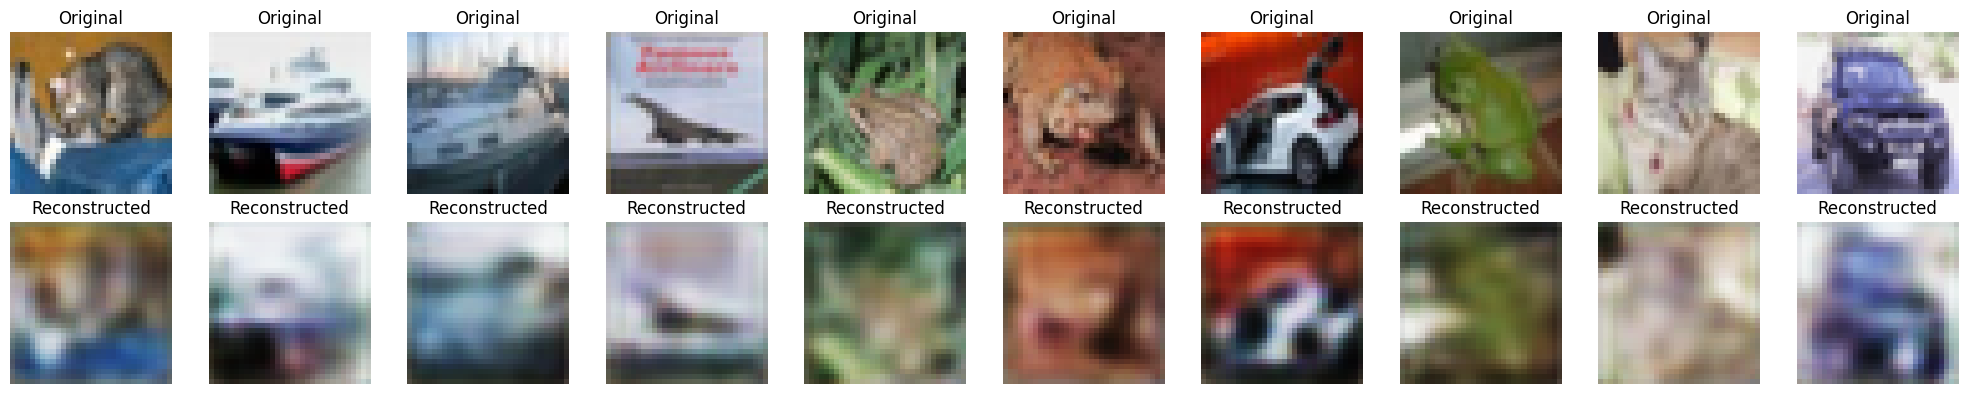

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, Flatten, Dense
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score

# ==========================================
# 1. Load Dataset and Normalize Pixel Values
# ==========================================
print("Loading and normalizing CIFAR-10 dataset...")
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalize pixel values to be between 0 and 1
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Flatten labels for sklearn compatibility
y_train_flat = y_train.flatten()
y_test_flat = y_test.flatten()

# ==========================================
# 2. Unsupervised Learning: Autoencoder for Compression
# ==========================================
print("Building and training Autoencoder...")

# Input placeholder
input_img = Input(shape=(32, 32, 3))

# Encoder (Compresses the image)
x = Conv2D(16, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2, 2), padding='same')(x)
x = Conv2D(8, (3, 3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2, 2), padding='same')(x) # Compressed representation (8x8x8 = 512 dims)

# Decoder (Reconstructs the image)
x = Conv2D(8, (3, 3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2, 2))(x)
x = Conv2D(16, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)
decoded = Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

# Compile models
autoencoder = Model(input_img, decoded)
encoder = Model(input_img, encoded) # We can use this to extract features later

autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# Train Autoencoder (using a small number of epochs for demonstration)
autoencoder.fit(x_train, x_train,
                epochs=5,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test, x_test),
                verbose=1)



# [Image of an autoencoder neural network architecture]


# ==========================================
# 3. Supervised Model: Convolutional Neural Network (CNN) on RAW Images
# ==========================================
print("Building and training CNN on raw images...")
cnn = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train CNN
history_cnn = cnn.fit(x_train, y_train, epochs=5, batch_size=64, validation_data=(x_test, y_test), verbose=1)

# Evaluate CNN
cnn_loss, cnn_accuracy = cnn.evaluate(x_test, y_test, verbose=0)
print(f"--> CNN Accuracy (Raw Images): {cnn_accuracy * 100:.2f}%\n")

# ==========================================
# 4. Supervised Model: SVM on Compressed Features (Using PCA)
# ==========================================
# Note: We use PCA here to easily compress features down to a 1D vector suited for SVMs.
print("Extracting features using PCA and training SVM...")

# Flatten images for PCA
x_train_flat = x_train.reshape(-1, 32 * 32 * 3)
x_test_flat = x_test.reshape(-1, 32 * 32 * 3)

# Apply PCA to compress features down to 128 components
pca = PCA(n_components=128)
x_train_pca = pca.fit_transform(x_train_flat)
x_test_pca = pca.transform(x_test_flat)

# Train SVM
# Note: SVMs scale quadratically with sample size. We use a subset of 10,000 training samples to keep runtime reasonable.
subset_size = 10000
svm_classifier = SVC(kernel='rbf', C=1.0)
svm_classifier.fit(x_train_pca[:subset_size], y_train_flat[:subset_size])

# Evaluate SVM
svm_predictions = svm_classifier.predict(x_test_pca)
svm_accuracy = accuracy_score(y_test_flat, svm_predictions)
print(f"--> SVM Accuracy (PCA Compressed Features): {svm_accuracy * 100:.2f}%\n")

# ==========================================
# 5. Visualize Reconstructed Images from Autoencoder
# ==========================================
print("Visualizing reconstructions...")
decoded_imgs = autoencoder.predict(x_test)

n = 10  # Number of images to display
plt.figure(figsize=(20, 4))
for i in range(n):
    # Display original raw images
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i])
    plt.title("Original")
    plt.axis('off')

    # Display autoencoder reconstructions
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i])
    plt.title("Reconstructed")
    plt.axis('off')

plt.tight_layout()
plt.show()